# Lead-to-Payment Conversion Analysis

There is a business process that consists of 4 stages:

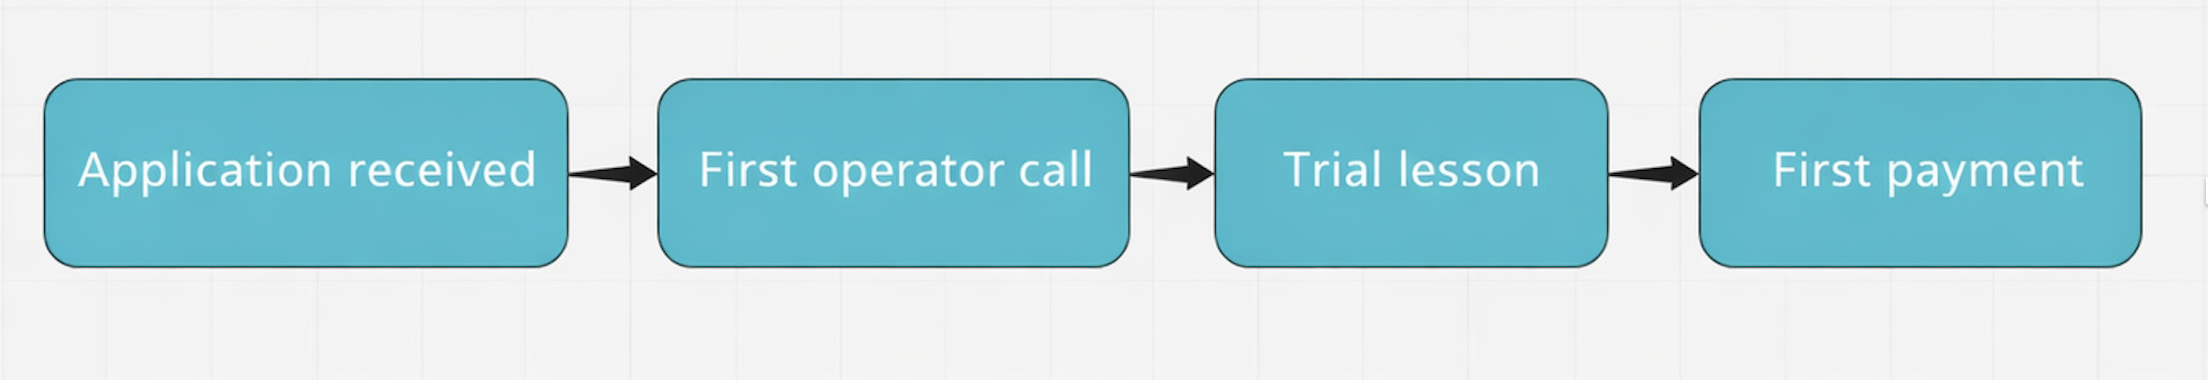

The operator makes a call to lead the client to a trial lesson. The trial lesson is free and is intended to demonstrate how the service works.

Our goal is to formulate hypotheses for increasing the conversion rate from application to payment, which is calculated as:
$$
C1 = \frac{number\ of\ first\ payments}{number\ of\ incoming\ applications}
$$

We have a dataset with the following fields:
```
0 order_id - order ID
1 source - where the order came from
2 application_datetime - date the order was received
3 gender
4 first_call - time of the first operator call
5 first_reach - time of the operator call the client answered
6 operator_group_type - type of line 1 operator group
7 operator_group_name - name of line 1 operator group
8 trial_appointment_datetime - date of the trial lesson
9 appointment_added_by_id - ID of the operator who scheduled the trial lesson
10 is_paid - first payment received = 1, not received = 0
```

## Goal
Examine the data and formulate several hypotheses that could influence the conversion rate from lead to first payment. Recommendations should be formulated so that a non-technical person (e.g., a sales manager) can make a business decision.


## Import libraries

In [214]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Load data

In [215]:
df = pd.read_csv("data.csv")
df.head()

,order_id,source,application_datetime,gender,first_call,first_reach,operator_group_type,operator_group_name,trial_appointment_datetime,appointment_added_by_id,is_paid
0,10457322,a636bcf354a837fb5c25c3d5b940170b,2020-04-03 04:10:45,1.0,2020-04-03 16:43:59.508792,2020-04-03 22:11:27.455366,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-04-04 15:28:14.798018,6620229,0
1,11236929,91ce888e6774bd668a675b5640499103,2020-07-12 03:31:39,NaN,2020-07-12 04:47:12.312267,2020-07-12 07:05:38.094529,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-07-12 15:02:07.545403,4578767,0
2,10246280,91ce888e6774bd668a675b5640499103,2020-02-01 03:19:28,NaN,2020-02-04 04:45:20.910754,2020-02-04 10:42:35.204203,e908f62885515872936a2bf07e5960a0,a0b8ef7535f9201f77c5a97d2ba4db2b,2020-02-02 07:07:41.388133,6290758,0
3,11058994,a636bcf354a837fb5c25c3d5b940170b,2020-05-19 06:18:16,0.0,2020-05-19 07:18:45.609637,2020-05-19 08:39:54.048419,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-05-19 13:01:02.901309,4700850,0
4,10265283,91ce888e6774bd668a675b5640499103,2020-02-09 21:59:18,NaN,2020-02-10 09:14:45.941424,2020-02-10 20:01:01.297674,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-02-11 05:33:59.680231,4500083,0


In [216]:
df.shape

(10000, 11)

## Data Quality Check

### missing values

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    10000 non-null  int64  
 1   source                      10000 non-null  object 
 2   application_datetime        10000 non-null  object 
 3   gender                      5084 non-null   float64
 4   first_call                  10000 non-null  object 
 5   first_reach                 9418 non-null   object 
 6   operator_group_type         10000 non-null  object 
 7   operator_group_name         10000 non-null  object 
 8   trial_appointment_datetime  10000 non-null  object 
 9   appointment_added_by_id     10000 non-null  int64  
 10  is_paid                     10000 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 859.5+ KB


In [218]:
dataquality_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null_cnt': df.notna().sum(),
    'null_cnt': df.isna().sum(),
    'null_share_pct': (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(dropna=True)
}).reset_index().rename(columns={'index': 'column'})

dataquality_summary

,column,dtype,non_null_cnt,null_cnt,null_share_pct,nunique
0,order_id,int64,10000,0,0.00,10000
1,source,object,10000,0,0.00,29
2,application_datetime,object,10000,0,0.00,9996
3,gender,float64,5084,4916,49.16,2
4,first_call,object,10000,0,0.00,10000
5,first_reach,object,9418,582,5.82,9418
6,operator_group_type,object,10000,0,0.00,3
7,operator_group_name,object,10000,0,0.00,24
8,trial_appointment_datetime,object,10000,0,0.00,10000
9,appointment_added_by_id,int64,10000,0,0.00,1101


Most columns have no missing values, except for `gender` (~49%) and `first_reach` (~6%). This may limit analysis for these features.

### data types

Here I check whether columns have consistent types and convert date-related fields to datetime format for further funnel and timing analysis.

In [219]:
mixed_type_summary = pd.DataFrame({
    'column': df.columns,
    'types_cnt': [df[col].map(type).nunique() for col in df.columns],
    'types': [list(df[col].map(type).unique()) for col in df.columns]
})

mixed_type_summary

,column,types_cnt,types
0,order_id,1,[<class 'int'>]
1,source,1,[<class 'str'>]
2,application_datetime,1,[<class 'str'>]
3,gender,1,[<class 'float'>]
4,first_call,1,[<class 'str'>]
5,first_reach,2,"[<class 'str'>, <class 'float'>]"
6,operator_group_type,1,[<class 'str'>]
7,operator_group_name,1,[<class 'str'>]
8,trial_appointment_datetime,1,[<class 'str'>]
9,appointment_added_by_id,1,[<class 'int'>]


In [220]:
mixed_type_summary[mixed_type_summary['types_cnt'] > 1]

,column,types_cnt,types
5,first_reach,2,"[<class 'str'>, <class 'float'>]"


In [221]:
for col in df.columns:
    types = df[col].map(type).unique()
    if len(types) > 1:
        print(f'\nColumn: {col}')
        for t in types:
            print(f'  Type: {t}')
            print(df.loc[df[col].map(type) == t, col].head(5).to_list())


Column: first_reach
  Type: <class 'str'>
['2020-04-03 22:11:27.455366', '2020-07-12 07:05:38.094529', '2020-02-04 10:42:35.204203', '2020-05-19 08:39:54.048419', '2020-02-10 20:01:01.297674']
  Type: <class 'float'>
[nan, nan, nan, nan, nan]


Most columns have consistent data types. Some columns (e.g., `first_reach`) contain both valid values and missing values (NaN), which is expected.

In [222]:
df = df.convert_dtypes()

date_cols = [
    'application_datetime',
    'first_call',
    'first_reach',
    'trial_appointment_datetime'
]

df[date_cols] = df[date_cols].apply(pd.to_datetime, errors='coerce')
df[date_cols].dtypes

application_datetime          datetime64[ns]
first_call                    datetime64[ns]
first_reach                   datetime64[ns]
trial_appointment_datetime    datetime64[ns]
dtype: object

### duplicates

In [223]:
full_duplicates_cnt = df.duplicated().sum()
full_duplicates_cnt

np.int64(0)

In [224]:
df['order_id'].duplicated().sum()

np.int64(0)

No full-row duplicates were found, and order_id is unique, which suggests that each record represents a distinct application.

### data consistency

In [225]:
df['gender'].value_counts(dropna=False)

gender
<NA>    4916
1       3018
0       2066
Name: count, dtype: Int64

In [226]:
df['source'].value_counts(dropna=False)

source
91ce888e6774bd668a675b5640499103    7918
4502821cb71c7f2195cd4e542273fe38     802
a636bcf354a837fb5c25c3d5b940170b     436
4cedf3fbf9f7dc88b37bc42c66908c06     131
2916b0834eaf3921234cdd5f2a3d0a3a     126
f12c0522bfa2143e29832a5f3bf7c0b5      99
f5bffc1a757263e7b8b397484d2737d7      58
e7d707a26e7f7b6ff52c489c60e429b1      53
2c3991193c1da7c9e7ea14adbaf4ea50      53
cd48e195ee1a590504a0515b4f9b41e8      50
ac237ddf527733d443d6e3440d49a970      49
0cbc9029b6168ca138da344f4a06c2f7      42
f1a1996543f7c52fb277501d7f8abed9      27
b26ad2c2638544ba42dd2c16c77dd91a      25
583eb722b77d6c7791d1811f6a42450c      24
2f57c79e2eeea3320dfdabe80ceecf64      24
bdcf5fc18e4f01990300ed0d0a306428      15
8fe139ceee6bc394d46b1e960606a3d1      13
b0521b815783c8a1c07cab1f61a43b27       8
a77d267d7c75b97b497e18d447f8b67e       8
302b25d9f5e394b656b20a70615a52af       8
86b0d8c2e04798d4b539e1e3f04e5a45       7
3f777e3bd400abe911a00a23a7891c52       5
2e27e68a4da0111ddf644ab75a93ac12       5
6d58a8f62

In [227]:
df['operator_group_type'].value_counts(dropna=False)

operator_group_type
a170e8b5b0085420fa52f9f9e1d546f9    6557
e908f62885515872936a2bf07e5960a0    3330
21790c97eeb6336e5f0fdb9ef4de636f     113
Name: count, dtype: Int64

In [228]:
df['operator_group_name'].value_counts(dropna=False)

operator_group_name
d4f622b69e50e86a65cd6fae4bcf575f    6495
a0b8ef7535f9201f77c5a97d2ba4db2b    3330
41fcb0f55a2687355fff238d3bdf319e      39
3b574fbbeb9251641816c6c5e8140e62      31
d6a7e0ab0512ccc44e702ea978ebc5df      30
c2e1985524a741220fbf9448ecc94d0e      20
63af698d7d79dadbc44ac71a068acea0      14
4066be2336930bd56d04cb32065ba808       8
73231aa8aa7a12c078c764b0fd686b34       5
6d208704ad0de706bd2da353ba4e4cb8       5
7048270b6e5da5858703cd2ef2998649       3
71f28acc49d59768329c29ca33acb36c       2
bec94779f5f3577acf456dda29461f53       2
01cf9adec108aa0cd5dc4e39c2af1e42       2
2d651a7c0cd492ac0ea68032f936f610       2
50b18bd0f19a885de1c8de8c46261398       2
27874c9802470669925ec02eb0c2fd64       2
798773b75454657007fb8b39efbc312a       2
edb56bd0223fe29944d00db73880c963       1
43c831a1511b89eeeb1c9086c4e90f35       1
583602883825b5ec01a226e77d08d41b       1
ff2fd2f0bf05f9ebdfbff51ccbac77c9       1
8fb9f6ee463b7588838293212f19a7ce       1
d6805ace660f687196d562c6dd4ecad0     

In [229]:
df['is_paid'].value_counts(dropna=False)

is_paid
1    5018
0    4982
Name: count, dtype: Int64

In [230]:
df['appointment_added_by_id'].value_counts(dropna=False).reset_index().sort_values('appointment_added_by_id')

,appointment_added_by_id,count
0,-2,1292
879,34062,1
226,69366,11
276,71114,8
783,74591,1
...,...,...
895,11278504,1
807,11278993,1
575,11283060,3
805,11283099,1


A noticeable share of trial lessons is associated with appointment_added_by_id = -2. This likely indicates a technical or non-standard assignment mechanism, so these cases may need to be interpreted separately from regular operator-assigned trials.

### logical inconsistencies in timestamps

In [231]:
df[df['first_call'] < df['application_datetime']]

,order_id,source,application_datetime,gender,first_call,first_reach,operator_group_type,operator_group_name,trial_appointment_datetime,appointment_added_by_id,is_paid
286,11472195,91ce888e6774bd668a675b5640499103,2020-09-15 00:40:40,1,2020-09-15 00:25:50.835423,2020-09-15 01:45:43.974623,e908f62885515872936a2bf07e5960a0,a0b8ef7535f9201f77c5a97d2ba4db2b,2020-09-15 07:30:16.670696,10501873,1
754,10567100,91ce888e6774bd668a675b5640499103,2020-04-30 11:32:28,0,2020-04-30 11:19:18.632157,2020-04-30 11:47:49.688479,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-04-30 13:45:54.401497,6344055,1
1404,11349342,91ce888e6774bd668a675b5640499103,2020-08-21 13:32:41,0,2020-08-21 13:29:31.629556,2020-08-21 13:32:10.585312,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-08-21 13:47:06.329101,5064182,0
1913,11155205,a636bcf354a837fb5c25c3d5b940170b,2020-06-23 18:30:18,0,2020-06-23 18:25:14.981290,2020-06-23 18:25:31.323930,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-06-23 18:32:00.012282,5962762,0
2079,10157783,91ce888e6774bd668a675b5640499103,2020-01-05 02:40:09,<NA>,2020-01-05 01:57:59.399312,2020-01-05 02:34:27.074094,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-01-05 05:31:46.231544,6344006,1
3275,10369833,91ce888e6774bd668a675b5640499103,2020-03-10 16:32:00,1,2020-03-10 16:27:25.619182,2020-03-10 16:37:39.125125,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-03-10 17:20:34.516015,6453822,1
3349,10449248,91ce888e6774bd668a675b5640499103,2020-04-03 00:16:29,1,2020-04-03 00:13:21.471964,2020-04-03 00:28:04.962175,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-04-03 01:29:26.256798,6344055,0
3560,10432931,91ce888e6774bd668a675b5640499103,2020-03-25 04:13:04,1,2020-03-25 04:04:29.389724,2020-03-25 04:12:00.663922,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-03-25 04:49:16.949756,5550269,1
3811,10432884,a636bcf354a837fb5c25c3d5b940170b,2020-03-26 01:09:05,1,2020-03-26 01:05:10.652772,2020-03-26 01:07:10.751306,a170e8b5b0085420fa52f9f9e1d546f9,3b574fbbeb9251641816c6c5e8140e62,2020-03-26 01:20:28.597831,5834867,0
3994,11862459,91ce888e6774bd668a675b5640499103,2020-12-06 04:57:58,1,2020-12-06 04:52:42.138320,2020-12-06 04:55:10.091738,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-12-06 05:09:49.155432,10647201,1


Some records violate the expected chronological order of events, which may indicate data entry errors or inconsistencies in logging.

In [232]:
(df['first_call'] < df['application_datetime']).mean() * 100

np.float64(0.13)

Only 0.13% of records violate the expected chronological order, indicating that such inconsistencies are rare.

In [233]:
df[df['first_reach'] < df['first_call']]

,order_id,source,application_datetime,gender,first_call,first_reach,operator_group_type,operator_group_name,trial_appointment_datetime,appointment_added_by_id,is_paid


In [234]:
df[df['trial_appointment_datetime'] < df['application_datetime']]

,order_id,source,application_datetime,gender,first_call,first_reach,operator_group_type,operator_group_name,trial_appointment_datetime,appointment_added_by_id,is_paid


In [235]:
df[df['first_call'].isna() & df['first_reach'].notna()]

,order_id,source,application_datetime,gender,first_call,first_reach,operator_group_type,operator_group_name,trial_appointment_datetime,appointment_added_by_id,is_paid


In [236]:
df[df['trial_appointment_datetime'].notna() & df['first_reach'].isna()]

,order_id,source,application_datetime,gender,first_call,first_reach,operator_group_type,operator_group_name,trial_appointment_datetime,appointment_added_by_id,is_paid
5,11391888,4502821cb71c7f2195cd4e542273fe38,2020-09-03 22:46:59,0,2020-09-03 23:00:16.098750,NaT,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-09-21 01:14:13.178574,3968432,1
39,11401872,91ce888e6774bd668a675b5640499103,2020-08-28 19:00:12,1,2020-08-28 22:15:18.181201,NaT,e908f62885515872936a2bf07e5960a0,a0b8ef7535f9201f77c5a97d2ba4db2b,2020-08-30 18:45:40.678105,1450544,0
59,10418169,91ce888e6774bd668a675b5640499103,2020-04-01 09:45:04,<NA>,2020-04-04 19:19:02.523160,NaT,e908f62885515872936a2bf07e5960a0,a0b8ef7535f9201f77c5a97d2ba4db2b,2020-04-02 07:28:07.315812,5776319,1
61,10170277,91ce888e6774bd668a675b5640499103,2020-01-10 04:47:55,<NA>,2020-01-11 01:11:16.080670,NaT,e908f62885515872936a2bf07e5960a0,a0b8ef7535f9201f77c5a97d2ba4db2b,2020-01-10 14:39:14.958765,6343139,1
79,11448411,91ce888e6774bd668a675b5640499103,2020-09-12 14:44:11,<NA>,2020-09-16 20:11:23.983257,NaT,e908f62885515872936a2bf07e5960a0,a0b8ef7535f9201f77c5a97d2ba4db2b,2020-09-12 17:39:20.745307,-2,1
...,...,...,...,...,...,...,...,...,...,...,...
9899,10308090,91ce888e6774bd668a675b5640499103,2020-02-25 13:00:48,<NA>,2020-02-25 14:15:35.272991,NaT,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-02-26 00:57:14.695149,6956527,1
9903,11637732,91ce888e6774bd668a675b5640499103,2020-10-22 21:26:52,<NA>,2020-10-22 23:39:12.417393,NaT,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-10-23 17:30:38.832311,-2,1
9905,11395745,91ce888e6774bd668a675b5640499103,2020-09-03 02:28:14,<NA>,2020-09-03 18:27:45.509355,NaT,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,2020-09-04 16:14:13.041480,-2,1
9925,10441211,a636bcf354a837fb5c25c3d5b940170b,2020-03-24 22:17:56,1,2020-03-26 15:57:26.172839,NaT,e908f62885515872936a2bf07e5960a0,a0b8ef7535f9201f77c5a97d2ba4db2b,2020-03-25 13:12:20.027038,1450544,0


Some records show trial appointments scheduled without a successful contact. Although this might appear as a data inconsistency at first glance, it aligns with the business process, where the flow is Application → Call → Trial → Payment, and reaching the client (first_reach) is not required for scheduling a trial. This indicates that trial lessons can be assigned without direct contact.

In [237]:
df[df['trial_appointment_datetime'].notna() & df['first_call'].isna()]

,order_id,source,application_datetime,gender,first_call,first_reach,operator_group_type,operator_group_name,trial_appointment_datetime,appointment_added_by_id,is_paid


In [238]:
df[df['is_paid'] == 1]['trial_appointment_datetime'].isna().sum()

np.int64(0)

In [239]:
df['appointment_added_by_id'].isna().sum()

np.int64(0)

In [240]:
df[
    df['trial_appointment_datetime'].notna()
    & df['appointment_added_by_id'].isna()
]

,order_id,source,application_datetime,gender,first_call,first_reach,operator_group_type,operator_group_name,trial_appointment_datetime,appointment_added_by_id,is_paid


In [241]:
funnel_missing = pd.DataFrame({
    'step': [
        'application_datetime',
        'first_call',
        'first_reach',
        'trial_appointment_datetime',
        'is_paid'
    ],
    'null_cnt': [
        df['application_datetime'].isna().sum(),
        df['first_call'].isna().sum(),
        df['first_reach'].isna().sum(),
        df['trial_appointment_datetime'].isna().sum(),
        df['is_paid'].isna().sum()
    ]
})

funnel_missing['null_share_pct'] = (
    funnel_missing['null_cnt'] / len(df) * 100
).round(2)

funnel_missing

,step,null_cnt,null_share_pct
0,application_datetime,0,0.00
1,first_call,0,0.00
2,first_reach,582,5.82
3,trial_appointment_datetime,0,0.00
4,is_paid,0,0.00


The dataset was checked for missing values, duplicates, data types, and logical consistency.

No duplicate records were found, and order_id is unique, which confirms the integrity of the primary key.

Most columns do not contain missing values. However, gender has a high share of missing values (~49%), which may limit the reliability of gender-based analysis. Missing values in first_reach likely reflect users who were not successfully contacted, which is consistent with the funnel structure.

Data type inspection revealed that most columns are consistent.

Logical checks revealed some inconsistencies:

- there are cases where first_call occurs before `application_datetime`
- there are cases where a trial appointment is scheduled without a successful contact (`first_reach` is missing)

Overall, the dataset is suitable for analysis, but several issues — particularly inconsistent timestamps and high missing rates in certain fields — should be addressed or carefully handled to ensure reliable results.

## Research on key metrics and dependencies

In [242]:
total = len(df)

first_call_rate = df['first_call'].notna().mean()
reach_rate = df['first_reach'].notna().mean()
trial_rate = df['trial_appointment_datetime'].notna().mean()
payment_rate = df['is_paid'].mean()

print(f"""
Funnel Overview:
Applications: {total}
First calls: {df['first_call'].notna().sum()} ({first_call_rate:.2%})
Reached: {df['first_reach'].notna().sum()} ({reach_rate:.2%})
Trials: {df['trial_appointment_datetime'].notna().sum()} ({trial_rate:.2%})
Payments: {df['is_paid'].sum()} ({payment_rate:.2%})
"""
)


Funnel Overview:
Applications: 10000
First calls: 10000 (100.00%)
Reached: 9418 (94.18%)
Trials: 10000 (100.00%)
Payments: 5018 (50.18%)



Reminder: business process is the following: `Application → Call → Trial → Payment`

Insights:
- In data quality analysis we discovered that `first_reach` is not neccesary to book trial date
- It is important to note that trial_appointment_datetime reflects a scheduled trial lesson, but does not necessarily mean that the user actually attended it. This may affect the conversion to payment, as users who do not attend the trial are unlikely to convert.

The funnel shows no drop-offs before the trial stage, while the main conversion loss occurs at payment. This suggests that improving trial quality or user qualification could significantly increase overall conversion.

In [243]:
funnel = pd.DataFrame({
    'stage': [
        'Application',
        'First Call',
        'Trial Scheduled',
        'Paid'
    ],
    'count': [
        len(df),
        df['first_call'].notna().sum(),
        df['trial_appointment_datetime'].notna().sum(),
        df['is_paid'].sum()
    ]
})

funnel['conversion_from_prev'] = (
    funnel['count'] / funnel['count'].shift(1)
)

funnel['conversion_from_prev'] = funnel['conversion_from_prev'].fillna(1)

funnel['conversion_pct'] = (funnel['conversion_from_prev'] * 100).round(2)

funnel_table = pd.DataFrame({
    'group': ['Users_count', 'Conversion'],

    'Application': [
        len(df),
        100.0
    ],

    'Application → First Call': [
        df['first_call'].notna().sum(),
        df['first_call'].notna().mean() * 100
    ],

    'First Call → Trial': [
        df.loc[df['first_call'].notna(), 'trial_appointment_datetime'].notna().sum(),
        df.loc[df['first_call'].notna(), 'trial_appointment_datetime'].notna().mean() * 100
    ],

    'Trial → Payment': [
        df.loc[df['trial_appointment_datetime'].notna(), 'is_paid'].sum(),
        df.loc[df['trial_appointment_datetime'].notna(), 'is_paid'].mean() * 100
    ],

    'Final Conversion (Application → Payment)': [
        df['is_paid'].sum(),
        df['is_paid'].mean() * 100
    ]
})


funnel_table_display = funnel_table.copy()
funnel_table_display.iloc[1, 1:] = (
    funnel_table_display.iloc[1, 1:]
    .astype(float)
    .map(lambda x: f'{x:.2f}%')
)

funnel_table_display.iloc[0, 1:] = (
    funnel_table_display.iloc[0, 1:]
    .astype(int)
    .map(lambda x: f'{x:,}'.replace(',', ' '))
)

funnel_table_display

,group,Application,Application → First Call,First Call → Trial,Trial → Payment,Final Conversion (Application → Payment)
0,Users_count,10 000,10 000,10 000,5 018,5 018
1,Conversion,100.00%,100.00%,100.00%,50.18%,50.18%


There is no drop-off before the trial stage, which means the process does not filter users early. The main loss happens at the payment stage.

This indicates that the process does not filter or qualify users prior to the trial. As a result, the entire variation in conversion is concentrated at the payment stage, which becomes the key bottleneck.

Possible reasons for the drop at the payment stage may include:
- quality of the trial lesson
- low perceived value after the trial
- mismatch between expectations and actual experience
- pricing issues
- insufficient qualification of leads before the trial
- operator performance during trial scheduling

Operator performance is a relevant factor, as operators are responsible for contacting the client, communicating product value, and scheduling the trial lesson. Their actions may influence both trial attendance and the likelihood of conversion to payment.

In addition, the quality of the trial lesson itself may play a significant role. Variability in how instructors conduct the trial (e.g., communication, engagement, or clarity of value) can affect users’ perceived value and their decision to convert.

**Note:** `trial_appointment_datetime` reflects scheduling, not actual attendance. This may overestimate conversion at the trial stage.

### Funnel Recommendations
1. Improve trial-to-payment conversion (highest impact)

Focus on improving conversion after the trial stage, as this is the main bottleneck in the funnel.

Key actions:
- enhance trial lesson quality and structure
- ensure clear communication of product value
- align trial experience with user expectations

2. Introduce lead qualification before trial

Currently, all users are assigned a trial, which may reduce overall efficiency.

Key actions:
- introduce basic qualification criteria (e.g., interest level, intent)
- prioritize higher-quality leads
- consider filtering or segmenting users before trial

3. Analyze and improve operator performance

Operator actions may influence both trial attendance and conversion.

Key actions:
- compare conversion rates across operator groups
- identify best-performing practices
- standardize communication scripts and processes

4. Optimize trial experience

Trial lesson quality is a key driver of perceived value.

Key actions:
- standardize trial structure and content
- train instructors to improve engagement and clarity
- ensure the trial clearly demonstrates product benefits

5. Align pricing and value perception

Users may not convert if perceived value does not match expectations.

Key actions:
- review pricing strategy
- improve communication of value proposition
- consider targeted offers or incentives after trial

6. Improve measurement of trial effectiveness

Current data captures scheduled trials, but not actual attendance.

Key actions:
- track trial attendance explicitly
- analyze conversion separately for attended vs non-attended trials
- use this to better understand true conversion drivers

## Hypotheses and Validation

Based on the funnel analysis, several hypotheses were formulated to identify potential drivers of conversion.

In [244]:
def paid_stats_info(group_by_var):
    """
    Calculate conversion metrics by a given grouping variable:
    - number of applications
    - number of payments
    - conversion rate (%)
    - share of total traffic (%)
    """

    df_copy = df.copy()

    if group_by_var == 'gender':
        df_copy[group_by_var] = (
            df_copy[group_by_var]
            .astype('object')
            .fillna('Unknown')
        )

    stats = (
    df_copy.groupby(group_by_var)['is_paid']
    .agg(conversion_rate=('mean'), applications_cnt=('count'), paying_users_cnt=('sum'))
    .reset_index()
    )

    stats['conversion_rate_pct'] = (
        stats['conversion_rate'] * 100
    ).round(2)

    stats['traffic_share_pct'] = (
        stats['applications_cnt'] / len(df_copy) * 100
    ).round(2)

    stats = stats.drop(columns=['conversion_rate'])

    return stats.sort_values('traffic_share_pct', ascending=False)

### Hypothesis 1: Traffic source affects conversion

Users from different sources may have different intent and quality.

In [245]:
source_stats = paid_stats_info('source')
source_stats

,source,applications_cnt,paying_users_cnt,conversion_rate_pct,traffic_share_pct
16,91ce888e6774bd668a675b5640499103,7918,3967,50.1,79.18
8,4502821cb71c7f2195cd4e542273fe38,802,397,49.5,8.02
17,a636bcf354a837fb5c25c3d5b940170b,436,228,52.29,4.36
9,4cedf3fbf9f7dc88b37bc42c66908c06,131,64,48.85,1.31
2,2916b0834eaf3921234cdd5f2a3d0a3a,126,60,47.62,1.26
25,f12c0522bfa2143e29832a5f3bf7c0b5,99,51,51.52,0.99
27,f5bffc1a757263e7b8b397484d2737d7,58,29,50.0,0.58
3,2c3991193c1da7c9e7ea14adbaf4ea50,53,28,52.83,0.53
24,e7d707a26e7f7b6ff52c489c60e429b1,53,30,56.6,0.53
23,cd48e195ee1a590504a0515b4f9b41e8,50,28,56.0,0.5


In [246]:
top_sources = source_stats[source_stats['applications_cnt'] > 50]['source']
source_stats[source_stats['applications_cnt'] > 50]

,source,applications_cnt,paying_users_cnt,conversion_rate_pct,traffic_share_pct
16,91ce888e6774bd668a675b5640499103,7918,3967,50.1,79.18
8,4502821cb71c7f2195cd4e542273fe38,802,397,49.5,8.02
17,a636bcf354a837fb5c25c3d5b940170b,436,228,52.29,4.36
9,4cedf3fbf9f7dc88b37bc42c66908c06,131,64,48.85,1.31
2,2916b0834eaf3921234cdd5f2a3d0a3a,126,60,47.62,1.26
25,f12c0522bfa2143e29832a5f3bf7c0b5,99,51,51.52,0.99
27,f5bffc1a757263e7b8b397484d2737d7,58,29,50.0,0.58
3,2c3991193c1da7c9e7ea14adbaf4ea50,53,28,52.83,0.53
24,e7d707a26e7f7b6ff52c489c60e429b1,53,30,56.6,0.53


Most of the traffic is concentrated in a single source (≈80% of all applications) with a conversion rate of ~50%, which closely matches the overall C1. This indicates that overall conversion is largely driven by this dominant source.

Although some variation in conversion exists across sources, the majority of high-volume sources show similar performance. This suggests that traffic source is not the main driver of conversion, and improvements should focus on internal funnel stages, particularly the trial-to-payment step.

—> Result: Conversion is similar across high-volume sources (~47–52%)  
—> Conclusion: Source is not a key driver of conversion

### Hypothesis 2: Operator performance affects conversion

Different operators may influence user decisions through communication and scheduling.

In [247]:
operator_group_type_stats = paid_stats_info('operator_group_type')
operator_group_type_stats

,operator_group_type,applications_cnt,paying_users_cnt,conversion_rate_pct,traffic_share_pct
1,a170e8b5b0085420fa52f9f9e1d546f9,6557,3320,50.63,65.57
2,e908f62885515872936a2bf07e5960a0,3330,1638,49.19,33.3
0,21790c97eeb6336e5f0fdb9ef4de636f,113,60,53.1,1.13


Most applications are handled by two operator types, and their conversion to payment is almost the same: 50.63% vs 49.19%. This means that operator type does not appear to have a strong impact on conversion overall.

The third operator type shows slightly higher conversion (53.1%), but it accounts for only 1.13% of total traffic, so this result is based on a very small number of users and should be treated with caution.

Overall, operator type is unlikely to be a key driver of conversion. It makes more sense to look at other factors, such as traffic source, trial experience, or the interaction between source and operator.

In [248]:
operator_group_type_source_stats = paid_stats_info(['source','operator_group_type'])
operator_group_type_source_stats[operator_group_type_source_stats['applications_cnt'] > 50].sort_values(['source', 'operator_group_type'])

,source,operator_group_type,applications_cnt,paying_users_cnt,conversion_rate_pct,traffic_share_pct
5,2916b0834eaf3921234cdd5f2a3d0a3a,a170e8b5b0085420fa52f9f9e1d546f9,87,39,44.83,0.87
17,4502821cb71c7f2195cd4e542273fe38,a170e8b5b0085420fa52f9f9e1d546f9,581,291,50.09,5.81
18,4502821cb71c7f2195cd4e542273fe38,e908f62885515872936a2bf07e5960a0,220,106,48.18,2.2
19,4cedf3fbf9f7dc88b37bc42c66908c06,a170e8b5b0085420fa52f9f9e1d546f9,110,54,49.09,1.1
35,91ce888e6774bd668a675b5640499103,a170e8b5b0085420fa52f9f9e1d546f9,5102,2582,50.61,51.02
36,91ce888e6774bd668a675b5640499103,e908f62885515872936a2bf07e5960a0,2790,1370,49.1,27.9
37,a636bcf354a837fb5c25c3d5b940170b,a170e8b5b0085420fa52f9f9e1d546f9,318,174,54.72,3.18
38,a636bcf354a837fb5c25c3d5b940170b,e908f62885515872936a2bf07e5960a0,118,54,45.76,1.18
58,f12c0522bfa2143e29832a5f3bf7c0b5,a170e8b5b0085420fa52f9f9e1d546f9,85,46,54.12,0.85


In [249]:
operator_group_name_stats = paid_stats_info('operator_group_name')
operator_group_name_stats

,operator_group_name,applications_cnt,paying_users_cnt,conversion_rate_pct,traffic_share_pct
19,d4f622b69e50e86a65cd6fae4bcf575f,6495,3286,50.59,64.95
16,a0b8ef7535f9201f77c5a97d2ba4db2b,3330,1638,49.19,33.3
5,41fcb0f55a2687355fff238d3bdf319e,39,22,56.41,0.39
3,3b574fbbeb9251641816c6c5e8140e62,31,19,61.29,0.31
21,d6a7e0ab0512ccc44e702ea978ebc5df,30,15,50.0,0.3
18,c2e1985524a741220fbf9448ecc94d0e,20,10,50.0,0.2
9,63af698d7d79dadbc44ac71a068acea0,14,7,50.0,0.14
4,4066be2336930bd56d04cb32065ba808,8,6,75.0,0.08
10,6d208704ad0de706bd2da353ba4e4cb8,5,4,80.0,0.05
13,73231aa8aa7a12c078c764b0fd686b34,5,1,20.0,0.05


Extreme conversion values across some operator groups are driven by very small sample sizes and should not be overinterpreted.

Almost the entire traffic is concentrated in two operator groups, and their conversion rates are very close (~49–51%). This suggests that operator group is unlikely to be a major standalone driver of conversion at the aggregate level.

In [250]:
operator_group_name_stats

,operator_group_name,applications_cnt,paying_users_cnt,conversion_rate_pct,traffic_share_pct
19,d4f622b69e50e86a65cd6fae4bcf575f,6495,3286,50.59,64.95
16,a0b8ef7535f9201f77c5a97d2ba4db2b,3330,1638,49.19,33.3
5,41fcb0f55a2687355fff238d3bdf319e,39,22,56.41,0.39
3,3b574fbbeb9251641816c6c5e8140e62,31,19,61.29,0.31
21,d6a7e0ab0512ccc44e702ea978ebc5df,30,15,50.0,0.3
18,c2e1985524a741220fbf9448ecc94d0e,20,10,50.0,0.2
9,63af698d7d79dadbc44ac71a068acea0,14,7,50.0,0.14
4,4066be2336930bd56d04cb32065ba808,8,6,75.0,0.08
10,6d208704ad0de706bd2da353ba4e4cb8,5,4,80.0,0.05
13,73231aa8aa7a12c078c764b0fd686b34,5,1,20.0,0.05


Some operator groups show very high or very low conversion, but this is mostly because they have very few users. These results are not reliable and should not be used for conclusions.

Almost all users are handled by two operator groups, and their conversion is very similar (around 49–51%). This means that, in general, the operator group by itself does not greatly affect the payment.

In general, both main operator groups perform at the same level, so there is no clear difference in their overall effectiveness.

In [251]:
operator_group_name_source_stats = paid_stats_info(['source', 'operator_group_name'])
operator_group_name_source_stats = operator_group_name_source_stats[operator_group_name_source_stats['source'] \
    .isin(top_sources)&(operator_group_name_source_stats['applications_cnt'] >= 50)] \
    .sort_values(['source', 'operator_group_name'])
operator_group_name_source_stats

,source,operator_group_name,applications_cnt,paying_users_cnt,conversion_rate_pct,traffic_share_pct
9,2916b0834eaf3921234cdd5f2a3d0a3a,d4f622b69e50e86a65cd6fae4bcf575f,87,39,44.83,0.87
28,4502821cb71c7f2195cd4e542273fe38,a0b8ef7535f9201f77c5a97d2ba4db2b,220,106,48.18,2.2
29,4502821cb71c7f2195cd4e542273fe38,d4f622b69e50e86a65cd6fae4bcf575f,571,283,49.56,5.71
33,4cedf3fbf9f7dc88b37bc42c66908c06,d4f622b69e50e86a65cd6fae4bcf575f,108,53,49.07,1.08
55,91ce888e6774bd668a675b5640499103,a0b8ef7535f9201f77c5a97d2ba4db2b,2790,1370,49.1,27.9
57,91ce888e6774bd668a675b5640499103,d4f622b69e50e86a65cd6fae4bcf575f,5062,2560,50.57,50.62
60,a636bcf354a837fb5c25c3d5b940170b,a0b8ef7535f9201f77c5a97d2ba4db2b,118,54,45.76,1.18
61,a636bcf354a837fb5c25c3d5b940170b,d4f622b69e50e86a65cd6fae4bcf575f,313,173,55.27,3.13
90,f12c0522bfa2143e29832a5f3bf7c0b5,d4f622b69e50e86a65cd6fae4bcf575f,85,46,54.12,0.85


Overall, operator groups perform similarly, as the two main groups have almost identical conversion (~49–51%) and handle most of the traffic.

When looking at specific traffic sources, we do see some differences between operator groups. However, these differences are based on relatively small numbers of users, so they should be interpreted with caution.

This means that while operator performance may vary in certain cases, there is not enough evidence to say that one group consistently performs better than another.

In [252]:
operator_group_name_type_stats = paid_stats_info(['operator_group_type', 'operator_group_name'])
operator_group_name_type_stats = operator_group_name_type_stats[(operator_group_name_type_stats['applications_cnt'] >= 20)] \
    .sort_values(['operator_group_type', 'operator_group_name'])
operator_group_name_type_stats

,operator_group_type,operator_group_name,applications_cnt,paying_users_cnt,conversion_rate_pct,traffic_share_pct
4,21790c97eeb6336e5f0fdb9ef4de636f,41fcb0f55a2687355fff238d3bdf319e,39,22,56.41,0.39
16,21790c97eeb6336e5f0fdb9ef4de636f,c2e1985524a741220fbf9448ecc94d0e,20,10,50.0,0.2
19,a170e8b5b0085420fa52f9f9e1d546f9,3b574fbbeb9251641816c6c5e8140e62,31,19,61.29,0.31
20,a170e8b5b0085420fa52f9f9e1d546f9,d4f622b69e50e86a65cd6fae4bcf575f,6495,3286,50.59,64.95
21,a170e8b5b0085420fa52f9f9e1d546f9,d6a7e0ab0512ccc44e702ea978ebc5df,30,15,50.0,0.3
23,e908f62885515872936a2bf07e5960a0,a0b8ef7535f9201f77c5a97d2ba4db2b,3330,1638,49.19,33.3


Conversion is stable across operator groups. Differences exist, but they are either small or based on low traffic, so operator structure is not a key driver of performance.

In [253]:
df.groupby(df['appointment_added_by_id'] == -2)['is_paid'].mean().reset_index()

,appointment_added_by_id,is_paid
0,False,0.504019
1,True,0.486842


Trials with appointment_added_by_id = -2 show slightly lower conversion. If this reflects automatic assignment, it may suggest that operator involvement adds value, though this should be confirmed

—> Result: Conversion is similar across major operator groups (~49–51%), indicating no significant differences at the aggregate level.  
At the same time, a noticeable share of trials (~13%) is assigned with `appointment_added_by_id = -2` and shows slightly lower conversion (~48.7%) compared to operator-assigned trials (~50.4%).  
Most individual operators handle very small volumes, which makes their performance difficult to compare reliably.

—> Conclusion: There is no strong evidence that operator performance significantly affects conversion overall.  
However, trials assigned with `-2` perform slightly worse. If this value represents automatic assignment, it may suggest that operator involvement adds value, although this assumption requires validation.

### Hypothesis 3: User gender affect conversion

Different user segments may behave differently.


In [254]:
gender_stats = paid_stats_info('gender')
gender_stats

,gender,applications_cnt,paying_users_cnt,conversion_rate_pct,traffic_share_pct
2,Unknown,4916,2446,49.76,49.16
1,1,3018,1545,51.19,30.18
0,0,2066,1027,49.71,20.66


Conversion is almost the same across all gender groups (~49–51%). This means that gender does not appear to have a meaningful impact on payment conversion.

At the same time, almost half of the users (≈49%) have missing gender data (“Unknown”), which limits the ability to draw strong conclusions based on this factor.

—> Result: Conversion is similar across groups, with high missing data  
—> Conclusion: Gender is not a reliable driver

### Hypothesis 4: Response and scheduling speed affect conversion

It was assumed that faster user interaction (first call, successful contact, and trial scheduling) may increase the likelihood of conversion.

In [ ]:
df['time_to_call_hours'] = (
    df['first_call'] - df['application_datetime']
).dt.total_seconds() / 3600  # Calculate time between application and first call (in hours)

min_time = df['time_to_call_hours'].min()
max_time = df['time_to_call_hours'].max()


In [256]:
print(
    f"The minimal time from application till first call is {min_time:.2f} hours "
    f"(negative means call before application). \n"
    f"The longest time is {max_time:.2f} hours."
)

The minimal time from application till first call is -0.70 hours (negative means call before application). 
The longest time is 10225.21 hours.


In [257]:
df.groupby(pd.cut(df['time_to_call_hours'], bins=[min_time, 0,1,2,3,6,24,48,72,100, max_time]))['is_paid'].mean().reset_index()

,time_to_call_hours,is_paid
0,"(-0.703, 0.0]",0.583333
1,"(0.0, 1.0]",0.491601
2,"(1.0, 2.0]",0.486188
3,"(2.0, 3.0]",0.542199
4,"(3.0, 6.0]",0.520103
5,"(6.0, 24.0]",0.4889
6,"(24.0, 48.0]",0.499454
7,"(48.0, 72.0]",0.5
8,"(72.0, 100.0]",0.488701
9,"(100.0, 10225.215]",0.481422


Negative values mean that the call happened before the application, which is not possible in real life. These are data issues.

Very large delays (100+ hours) are also unrealistic and likely reflect logging errors or edge cases.

Conversion remains relatively stable regardless of how quickly the first call is made. There is no clear evidence that faster response time leads to higher conversion.

In [258]:
df['time_to_reach_hours'] = (
    df['first_reach'] - df['application_datetime']
).dt.total_seconds() / 3600

min_time = df['time_to_reach_hours'].min()
max_time = df['time_to_reach_hours'].max()

df.groupby(pd.cut(df['time_to_reach_hours'], bins=[min_time, 0,1,2,3,6,24,48,72,100, max_time]))['is_paid'].mean().reset_index()

,time_to_reach_hours,is_paid
0,"(-0.199, 0.0]",0.625
1,"(0.0, 1.0]",0.506329
2,"(1.0, 2.0]",0.514754
3,"(2.0, 3.0]",0.472313
4,"(3.0, 6.0]",0.505213
5,"(6.0, 24.0]",0.513129
6,"(24.0, 48.0]",0.489744
7,"(48.0, 72.0]",0.507216
8,"(72.0, 100.0]",0.506887
9,"(100.0, 10231.613]",0.481586


Conversion does not show a clear dependency on how quickly a user is successfully reached. Users convert at similar rates regardless of whether they are contacted quickly or later.

Neither time to first call nor time to reach appears to significantly impact conversion. This suggests that improving response speed alone is unlikely to increase payment conversion.

Conversion is more likely driven by factors related to the trial stage, such as user experience and perceived value, rather than early-stage timing.

In [259]:
df.groupby(df['first_reach'].notna())['is_paid'].mean()

first_reach
False    0.487973
True     0.502654
Name: is_paid, dtype: Float64

Users who were successfully reached convert slightly better (~50.3%) compared to those who were not (~48.8%). However, the difference is small and does not indicate a strong impact of reach on conversion.

In [260]:
df['time_to_trial_hours'] = (
    df['trial_appointment_datetime'] - df['application_datetime']
).dt.total_seconds() / 3600

min_time = df['time_to_trial_hours'].min()
max_time = df['time_to_trial_hours'].max()

df.groupby(pd.cut(df['time_to_trial_hours'], bins=[0,1,2,3,6,24,48,72,100,max_time]))['is_paid'].mean().reset_index()

,time_to_trial_hours,is_paid
0,"(0.0, 1.0]",0.464052
1,"(1.0, 2.0]",0.512346
2,"(2.0, 3.0]",0.507109
3,"(3.0, 6.0]",0.491007
4,"(6.0, 24.0]",0.498032
5,"(24.0, 48.0]",0.507941
6,"(48.0, 72.0]",0.5
7,"(72.0, 100.0]",0.547619
8,"(100.0, 9547.089]",0.48741


In [261]:
dependency_table = pd.DataFrame({
    'metric': [
        'Overall',
        'Reached',
        'Not reached'
    ],
    'conversion': [
        df['is_paid'].mean(),
        df[df['first_reach'].notna()]['is_paid'].mean(),
        df[df['first_reach'].isna()]['is_paid'].mean()
    ]
})

dependency_table

,metric,conversion
0,Overall,0.501800
1,Reached,0.502654
2,Not reached,0.487973


Since early-stage factors (source, operator, reach, timing) show little impact, the main opportunity to improve conversion likely lies in the trial experience and post-trial stage.

—> Result:  
- No clear relationship was found between time to first call and conversion  
- Reached users convert slightly better (~50.3% vs ~48.8%), but the difference is small  
- Conversion is similar across most time intervals for trial scheduling and shows no clear trend  

—> Conclusion:  
Speed of interaction (call, reach, and trial scheduling) does not significantly impact conversion.  
While successful contact has a small positive effect, overall timing-related factors are not key drivers of conversion.

### Hypothesis 5: Application timing affects conversion

It was assumed that the timing of application (weekday and time of day) may influence user intent and likelihood to convert.

In [262]:
df['application_weekday'] = df['application_datetime'].dt.day_name()

weekday_conversion = (
    df.groupby('application_weekday', as_index=False)
      .agg(
          applications_cnt=('order_id', 'count'),
          paid_cnt=('is_paid', 'sum'),
          conversion=('is_paid', 'mean')
      )
)

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

weekday_conversion['application_weekday'] = pd.Categorical(
    weekday_conversion['application_weekday'],
    categories=weekday_order,
    ordered=True
)

weekday_conversion = weekday_conversion.sort_values('application_weekday')
weekday_conversion['conversion_pct'] = weekday_conversion['conversion'] * 100

weekday_conversion

,application_weekday,applications_cnt,paid_cnt,conversion,conversion_pct
1,Monday,1389,704,0.506839,50.683945
5,Tuesday,1455,739,0.507904,50.790378
6,Wednesday,1415,707,0.499647,49.964664
4,Thursday,1448,708,0.48895,48.895028
0,Friday,1425,723,0.507368,50.736842
2,Saturday,1438,717,0.498609,49.860918
3,Sunday,1430,720,0.503497,50.34965


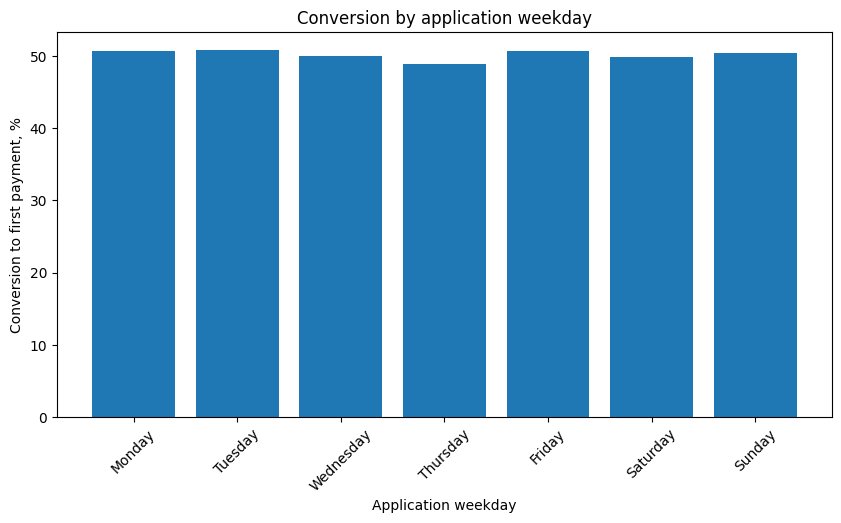

In [263]:
plt.figure(figsize=(10, 5))
plt.bar(weekday_conversion['application_weekday'], weekday_conversion['conversion_pct'])
plt.xlabel('Application weekday')
plt.ylabel('Conversion to first payment, %')
plt.title('Conversion by application weekday')
plt.xticks(rotation=45)
plt.show()

In [264]:
df['application_hour'] = df['application_datetime'].dt.hour

hour_conversion = (
    df.groupby('application_hour', as_index=False)
      .agg(
          applications_cnt=('order_id', 'count'),
          paid_cnt=('is_paid', 'sum'),
          conversion=('is_paid', 'mean')
      )
)

hour_conversion['conversion_pct'] = hour_conversion['conversion'] * 100
hour_conversion.sort_values('application_hour')

,application_hour,applications_cnt,paid_cnt,conversion,conversion_pct
0,0,429,220,0.512821,51.282051
1,1,421,198,0.470309,47.030879
2,2,419,211,0.50358,50.357995
3,3,429,224,0.522145,52.214452
4,4,418,211,0.504785,50.478469
5,5,425,210,0.494118,49.411765
6,6,422,219,0.518957,51.895735
7,7,425,201,0.472941,47.294118
8,8,418,238,0.569378,56.937799
9,9,374,186,0.497326,49.73262


In [265]:
def hour_segment(hour):
    if 0 <= hour < 6:
        return 'Night (00:00-05:59)'
    elif 6 <= hour < 12:
        return 'Morning (06:00-11:59)'
    elif 12 <= hour < 18:
        return 'Afternoon (12:00-17:59)'
    else:
        return 'Evening (18:00-23:59)'

df['application_time_segment'] = df['application_hour'].apply(hour_segment)

time_bucket_conversion = (
    df.groupby('application_time_segment', as_index=False)
      .agg(
          applications_cnt=('order_id', 'count'),
          paid_cnt=('is_paid', 'sum'),
          conversion=('is_paid', 'mean')
      )
)

segment_order = [
    'Night (00:00-05:59)',
    'Morning (06:00-11:59)',
    'Afternoon (12:00-17:59)',
    'Evening (18:00-23:59)'
]

time_bucket_conversion['application_time_segment'] = pd.Categorical(
    time_bucket_conversion['application_time_segment'],
    categories=segment_order,
    ordered=True
)

time_bucket_conversion = time_bucket_conversion.sort_values('application_time_segment')
time_bucket_conversion['conversion_pct'] = time_bucket_conversion['conversion'] * 100

time_bucket_conversion

,application_time_segment,applications_cnt,paid_cnt,conversion,conversion_pct
3,Night (00:00-05:59),2541,1274,0.501377,50.137741
2,Morning (06:00-11:59),2519,1267,0.502977,50.297737
0,Afternoon (12:00-17:59),2416,1179,0.487997,48.799669
1,Evening (18:00-23:59),2524,1298,0.514263,51.426307


—> Result:  
- Conversion is very similar across weekdays (~48.9%–50.8%)  
- Conversion varies slightly by hour, but the pattern is inconsistent  
- When grouped into broader time segments, conversion remains close (~48.8%–51.4%)  

—> Conclusion:  
Application timing (both weekday and time of day) does not significantly affect conversion.  
Some minor differences exist (e.g., slightly higher conversion in the evening), but they are small and do not represent a meaningful business opportunity.

## Hypotheses Summary

Several hypotheses were tested to identify potential drivers of conversion from application to payment.

- **Traffic source:** Conversion is similar across major sources —> not a key driver  
- **Operator performance:** Conversion is similar across main operator groups —> no strong impact  
- **Response & scheduling speed:** Timing of call, reach, and trial scheduling does not significantly affect conversion  
- **Application timing:** Weekday and time of application have no meaningful impact  
- **Successful contact (reach):** Slight positive effect (~1.5 p.p.), but impact is limited  
- **Trial assignment method:** Slightly lower conversion for `appointment_added_by_id = -2`; may indicate value of operator involvement (requires validation)

**Overall conclusion:**  
Most early-stage factors do not significantly influence conversion.  
The main opportunity lies in improving the trial experience and post-trial conversion.

## Business recommendations

#### 1. Focus on improving the trial experience
The main drop in conversion occurs after the trial stage.

- Improve trial structure and content  
- Clearly communicate product value during the trial  
- Align user expectations with actual experience  


#### 2. Improve conversion after the trial
Since most users reach the trial stage, increasing post-trial conversion will have the biggest impact.

- Add follow-ups after trial  
- Provide clear next steps and offers  
- Consider incentives or personalized offers  


#### 3. Review automatic trial assignment
A noticeable share of trials (~13%) is assigned with `appointment_added_by_id = -2` and shows slightly lower conversion.

- Validate whether this represents automatic assignment  
- Compare user experience between manual and automatic scheduling  
- Improve communication in automatic flows  


#### 4. Avoid over-investing in early funnel optimization
Factors such as source, operator, response speed, and reach show little impact on conversion.

- Do not prioritize changes in these areas  
- Focus resources on later stages of the funnel  


#### 5. Improve data quality and tracking
Some fields (e.g., gender, timing) contain missing or inconsistent values.

- Track actual trial attendance (not just scheduled)  
- Validate key fields (timestamps, assignment logic)  
- Improve data completeness  


#### 6. Personalize user experience where possible
Conversion may depend on user expectations and readiness rather than early interactions.

- Segment users by behavior or intent  
- Adapt communication and trial approach accordingly  